TASK 2: UNEMPLOYMENT ANALYSIS WITH PYTHON

AICTE Oasis Infobyte Internship

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

In [15]:
# HELPER: Create realistic sample dataset if CSV not found
def create_sample_data():
    """
    Creates a realistic sample unemployment dataset.
    Replace this with pd.read_csv('Unemployment in India.csv') if you
    have the actual dataset downloaded from the task link.
    """
    np.random.seed(42)
    regions = [
        'Andhra Pradesh', 'Bihar', 'Delhi', 'Gujarat', 'Haryana',
        'Himachal Pradesh', 'Jammu & Kashmir', 'Karnataka', 'Kerala',
        'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan',
        'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal',
        'Assam', 'Chhattisgarh'
    ]
    dates = pd.date_range(start='2019-01-01', end='2021-06-30', freq='MS')
    records = []
    for region in regions:
        base_rate = np.random.uniform(3, 12)
        for date in dates:
            # Simulate Covid spike in 2020
            covid_spike = 20 if (date.year == 2020 and date.month in range(4, 9)) else 0
            rate = base_rate + covid_spike + np.random.normal(0, 1.5)
            rate = max(1, rate)
            labour_participation = np.random.uniform(35, 55)
            employed = np.random.randint(5000, 50000)
            records.append({
                'Region': region,
                'Date': date,
                'Estimated Unemployment Rate (%)': round(rate, 2),
                'Estimated Employed': employed,
                'Estimated Labour Participation Rate (%)': round(labour_participation, 2),
                'Area': np.random.choice(['Urban', 'Rural'], p=[0.4, 0.6])
            })
    return pd.DataFrame(records)


In [16]:
# 1. LOAD DATASET
print("=" * 60)
print("       UNEMPLOYMENT ANALYSIS WITH PYTHON")
print("=" * 60)

try:
    df = pd.read_csv('Unemployment in India.csv')
    # Standardize column names
    df.columns = df.columns.str.strip()
    print("\n[1] Dataset loaded from CSV file.")
except FileNotFoundError:
    print("\n[1] CSV not found — using generated sample data.")
    print("    (Download the real dataset from the task link and place")
    print("     it as 'Unemployment in India.csv' in the same folder.)")
    df = create_sample_data()

print(f"    Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

       UNEMPLOYMENT ANALYSIS WITH PYTHON

[1] CSV not found — using generated sample data.
    (Download the real dataset from the task link and place
     it as 'Unemployment in India.csv' in the same folder.)
    Shape: (600, 6)

First 5 rows:
           Region       Date  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-01-01                             4.70   
1  Andhra Pradesh 2019-02-01                             6.85   
2  Andhra Pradesh 2019-03-01                             6.49   
3  Andhra Pradesh 2019-04-01                             6.13   
4  Andhra Pradesh 2019-05-01                             3.78   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0               42194                                    38.12  Rural  
1               21023                                    41.67  Rural  
2                7433                                    53.77  Urban  
3               24769                                    38.67  Rural  
4  

In [17]:
# 2. DATA CLEANING & PREPROCESSING
print("\n[2] Data Cleaning...")

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', ' ')

# Parse Date
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
elif 'Month' in df.columns:
    df['Date'] = pd.to_datetime(df['Month'], dayfirst=True, errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

# Identify unemployment rate column
unemp_col = [c for c in df.columns if 'unemployment' in c.lower() or 'unemp' in c.lower()]
unemp_col = unemp_col[0] if unemp_col else 'Estimated Unemployment Rate (%)'

region_col = [c for c in df.columns if 'region' in c.lower() or 'state' in c.lower()]
region_col = region_col[0] if region_col else 'Region'

area_col = [c for c in df.columns if 'area' in c.lower()]
area_col = area_col[0] if area_col else None

print(f"    Unemployment column : {unemp_col}")
print(f"    Region column       : {region_col}")
print(f"    Missing values:\n{df[[unemp_col, region_col]].isnull().sum()}")

df.dropna(subset=[unemp_col], inplace=True)
print(f"    Cleaned shape: {df.shape}")
print(f"\nStatistical Summary:\n{df[unemp_col].describe()}")


[2] Data Cleaning...
    Unemployment column : Estimated Unemployment Rate (%)
    Region column       : Region
    Missing values:
Estimated Unemployment Rate (%)    0
Region                             0
dtype: int64
    Cleaned shape: (600, 9)

Statistical Summary:
count    600.000000
mean      11.240183
std        8.062077
min        1.000000
25%        5.930000
50%        9.140000
75%       11.920000
max       34.190000
Name: Estimated Unemployment Rate (%), dtype: float64



[3] Generating EDA Visualizations...


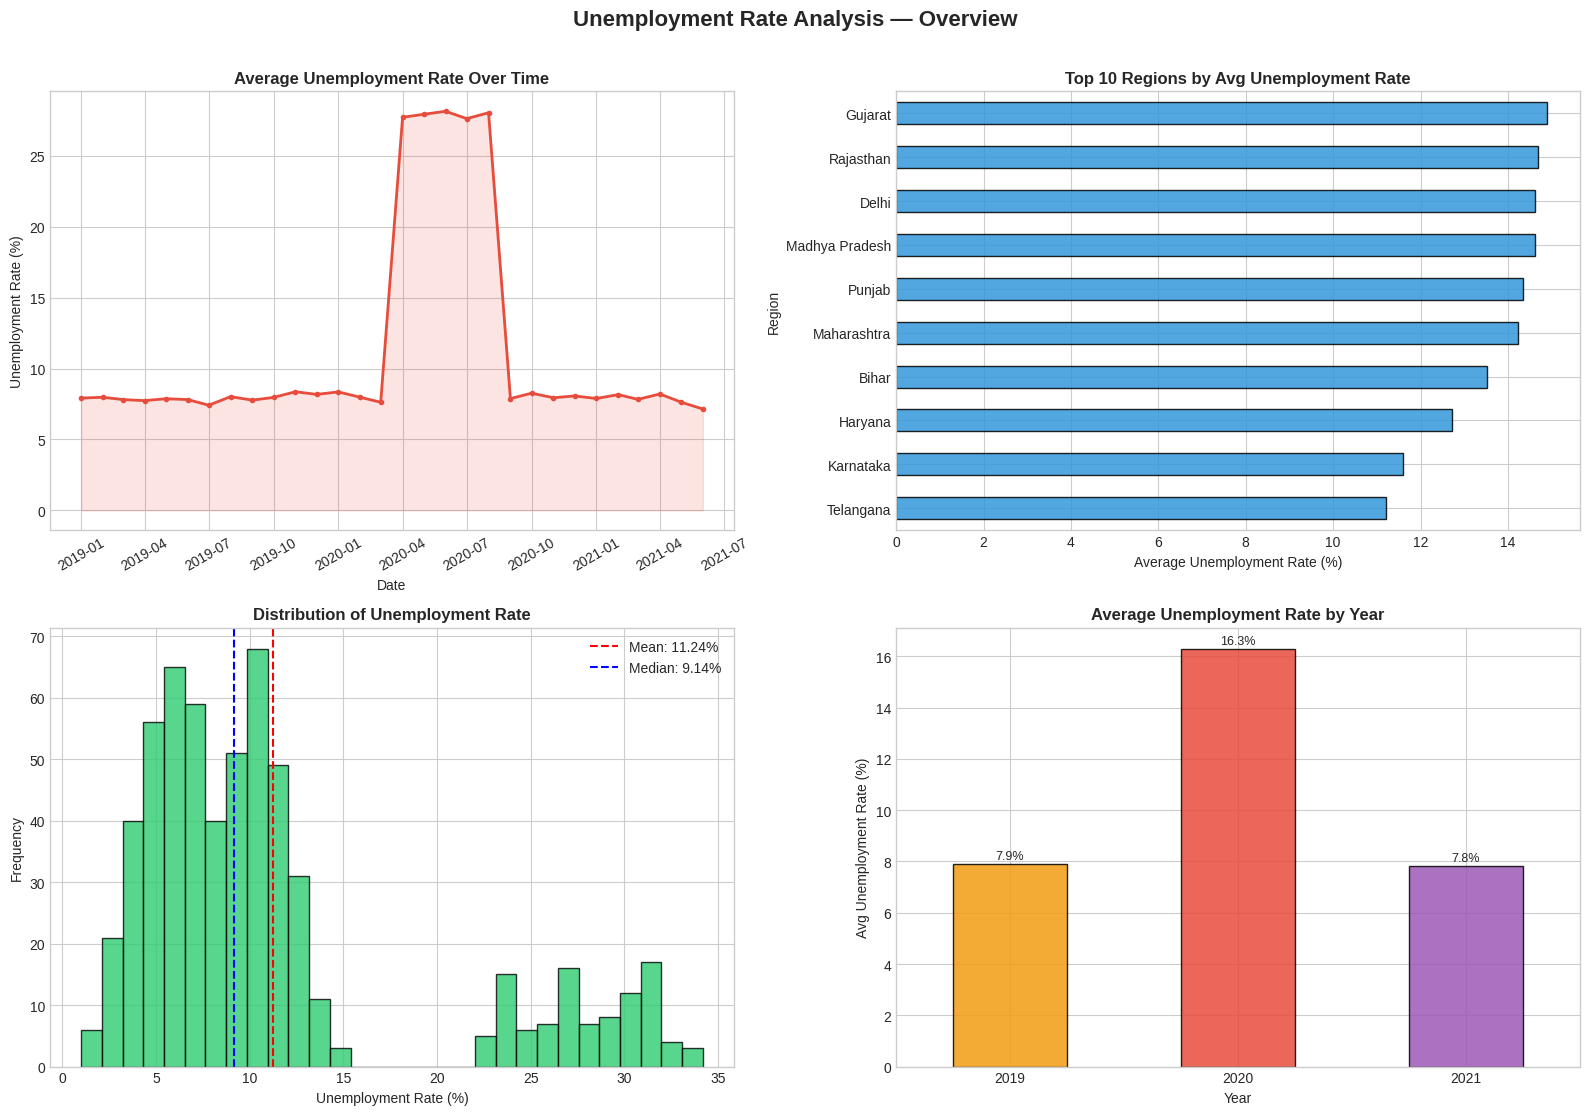

    Saved: unemployment_overview.png


In [27]:
# 3. EXPLORATORY DATA ANALYSIS
print("\n[3] Generating EDA Visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Unemployment Rate Analysis — Overview", fontsize=16, fontweight='bold', y=1.01)

# 3a. Trend over time
trend = df.groupby('Date')[unemp_col].mean().reset_index()
axes[0, 0].plot(trend['Date'], trend[unemp_col], color='#e74c3c', linewidth=2, marker='o', markersize=3)
axes[0, 0].fill_between(trend['Date'], trend[unemp_col], alpha=0.15, color='#e74c3c')
axes[0, 0].set_title('Average Unemployment Rate Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Unemployment Rate (%)')
axes[0, 0].tick_params(axis='x', rotation=30)

# 3b. Top regions by average unemployment
region_avg = df.groupby(region_col)[unemp_col].mean().sort_values(ascending=False).head(10)
region_avg.plot(kind='barh', ax=axes[0, 1], color='#3498db', alpha=0.85, edgecolor='black')
axes[0, 1].set_title('Top 10 Regions by Avg Unemployment Rate', fontweight='bold')
axes[0, 1].set_xlabel('Average Unemployment Rate (%)')
axes[0, 1].invert_yaxis()

# 3c. Distribution of unemployment rate
axes[1, 0].hist(df[unemp_col], bins=30, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(df[unemp_col].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df[unemp_col].mean():.2f}%")
axes[1, 0].axvline(df[unemp_col].median(), color='blue', linestyle='--', linewidth=1.5, label=f"Median: {df[unemp_col].median():.2f}%")
axes[1, 0].set_title('Distribution of Unemployment Rate', fontweight='bold')
axes[1, 0].set_xlabel('Unemployment Rate (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 3d. Yearly comparison
year_avg = df.groupby('Year')[unemp_col].mean()
year_avg.plot(kind='bar', ax=axes[1, 1], color=['#f39c12', '#e74c3c', '#9b59b6'], edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Average Unemployment Rate by Year', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Avg Unemployment Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=0)
for bar in axes[1, 1].patches:
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('unemployment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: unemployment_overview.png")

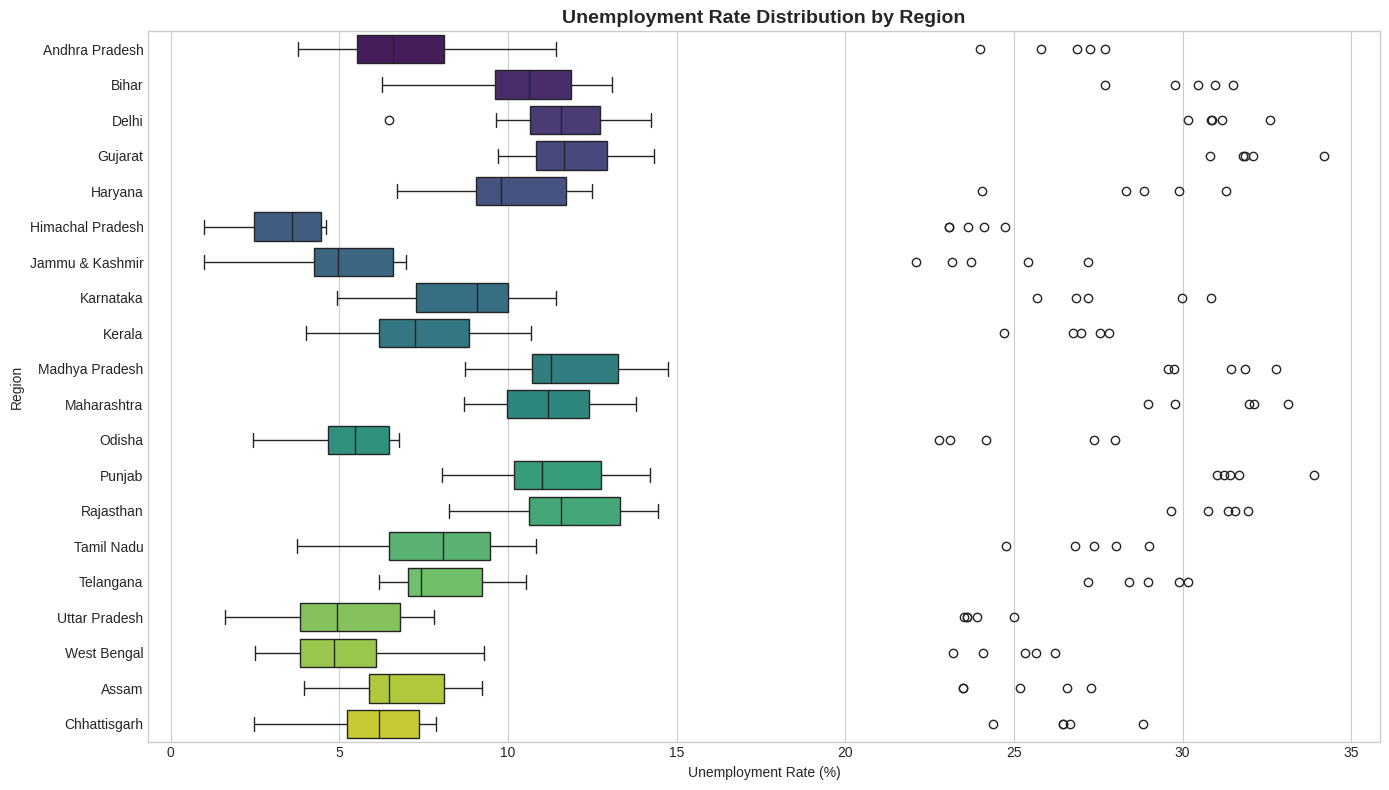

    Saved: unemployment_regional_boxplot.png


In [28]:
# 3e. Boxplot of Unemployment Rate by Region
plt.figure(figsize=(14, 8))
sns.boxplot(x=unemp_col, y=region_col, data=df, palette='viridis')
plt.title('Unemployment Rate Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('unemployment_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('    Saved: unemployment_regional_boxplot.png')

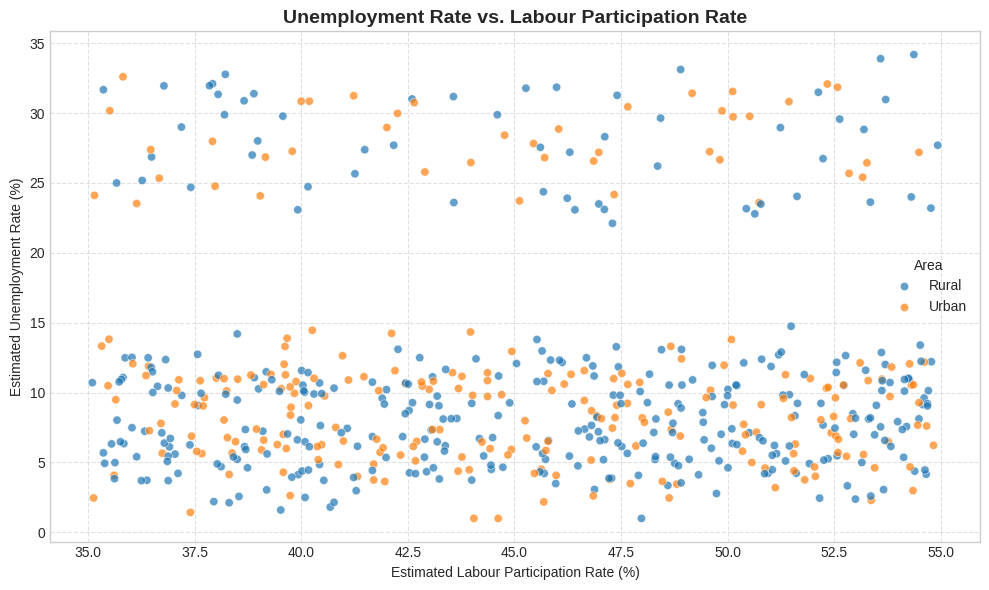

    Saved: unemployment_vs_participation_scatter.png


In [29]:
# 3f. Scatter plot: Unemployment Rate vs. Labour Participation Rate
if 'Estimated Labour Participation Rate (%)' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Estimated Labour Participation Rate (%)', y=unemp_col, data=df, hue='Area', alpha=0.7)
    plt.title('Unemployment Rate vs. Labour Participation Rate', fontsize=14, fontweight='bold')
    plt.xlabel('Estimated Labour Participation Rate (%)')
    plt.ylabel('Estimated Unemployment Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('unemployment_vs_participation_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('    Saved: unemployment_vs_participation_scatter.png')
else:
    print('    "Estimated Labour Participation Rate (%)" column not found for scatter plot.')


[4] COVID-19 Impact Analysis...

Period Comparison:
                              mean  median    max   std
Period                                                 
During COVID (Apr–Oct 2020)  22.23   25.74  34.19  9.50
Pre/Post COVID                7.89    7.65  14.75  3.07


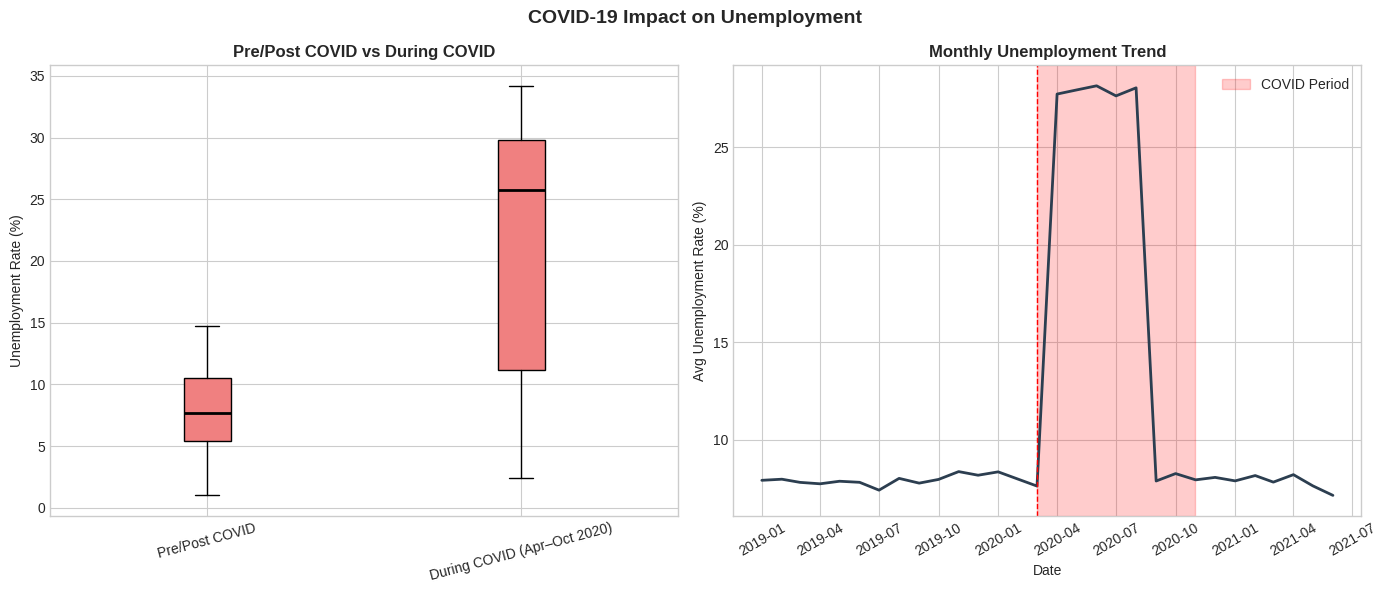

    Saved: unemployment_covid_impact.png


In [30]:
# 4. COVID-19 IMPACT ANALYSIS
print("\n[4] COVID-19 Impact Analysis...")

# Pre-Covid vs Covid period
df['Period'] = df['Date'].apply(
    lambda x: 'During COVID (Apr–Oct 2020)'
    if (x.year == 2020 and x.month in range(4, 11))
    else 'Pre/Post COVID'
)

period_stats = df.groupby('Period')[unemp_col].agg(['mean', 'median', 'max', 'std'])
print(f"\nPeriod Comparison:\n{period_stats.round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("COVID-19 Impact on Unemployment", fontsize=14, fontweight='bold')

# Boxplot
bp_data = [df[df['Period'] == p][unemp_col].values for p in df['Period'].unique()]
bp_labels = list(df['Period'].unique())
bplot = axes[0].boxplot(bp_data, labels=bp_labels, patch_artist=True,
                        boxprops=dict(facecolor='lightcoral'), medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Pre/Post COVID vs During COVID', fontweight='bold')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# Monthly trend with Covid period shaded
monthly = df.groupby('Date')[unemp_col].mean().reset_index()
axes[1].plot(monthly['Date'], monthly[unemp_col], color='#2c3e50', linewidth=2)
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2020-10-31')
axes[1].axvspan(covid_start, covid_end, alpha=0.2, color='red', label='COVID Period')
axes[1].axvline(covid_start, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Monthly Unemployment Trend', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Avg Unemployment Rate (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('unemployment_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: unemployment_covid_impact.png")


[5] Regional Analysis...


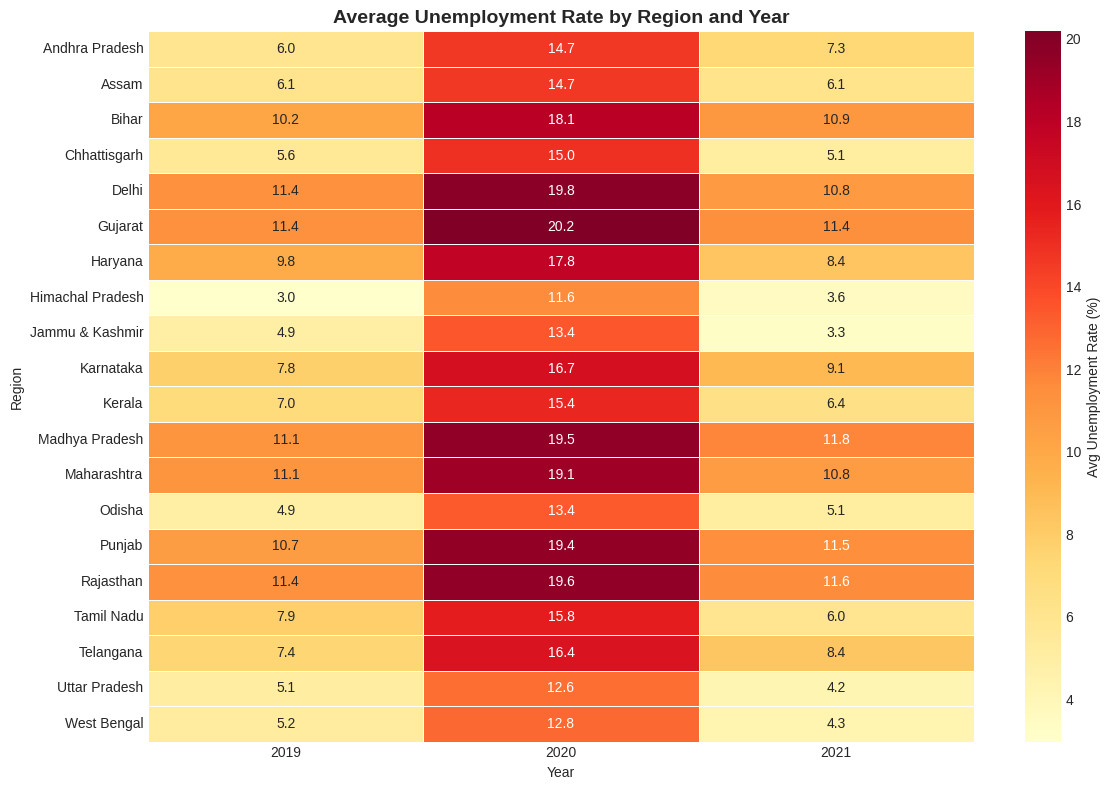

    Saved: unemployment_regional_heatmap.png


In [31]:
# 5. REGIONAL HEATMAP
print("\n[5] Regional Analysis...")

pivot = df.groupby([region_col, 'Year'])[unemp_col].mean().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Unemployment Rate (%)'})
plt.title('Average Unemployment Rate by Region and Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('unemployment_regional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: unemployment_regional_heatmap.png")


[6] Urban vs Rural Analysis...


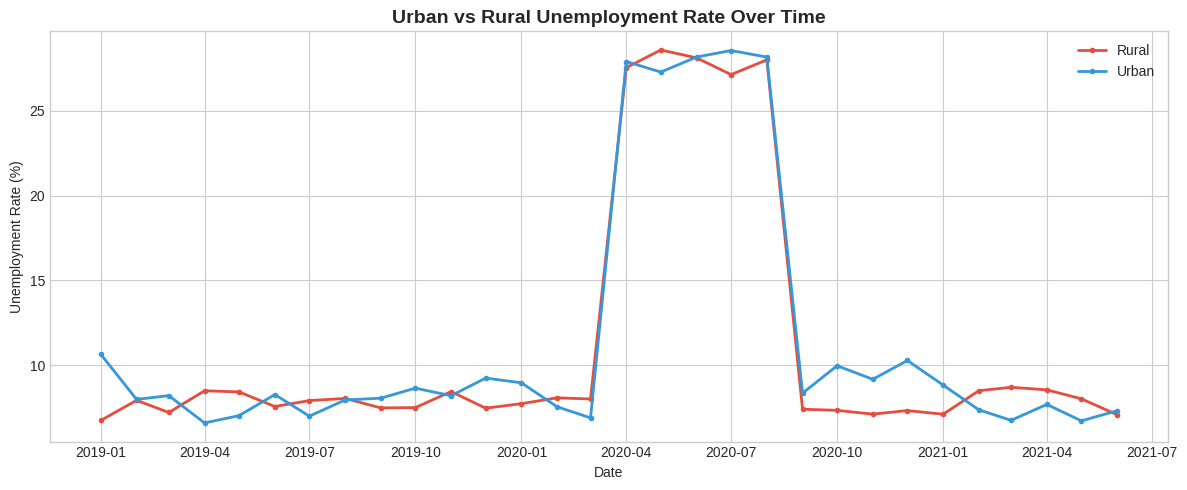

    Saved: unemployment_urban_rural.png


In [32]:
# 6. URBAN vs RURAL (if area column present)
if area_col and area_col in df.columns:
    print("\n[6] Urban vs Rural Analysis...")
    area_avg = df.groupby([area_col, 'Date'])[unemp_col].mean().reset_index()
    plt.figure(figsize=(12, 5))
    for area, color in zip(df[area_col].unique(), ['#e74c3c', '#3498db']):
        subset = area_avg[area_avg[area_col] == area]
        plt.plot(subset['Date'], subset[unemp_col], label=area, color=color, linewidth=2, marker='o', markersize=3)
    plt.title('Urban vs Rural Unemployment Rate Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Unemployment Rate (%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('unemployment_urban_rural.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("    Saved: unemployment_urban_rural.png")

In [24]:
# 7. TOP & BOTTOM REGIONS
print("\n[7] Key Regional Statistics:")
region_avg = df.groupby(region_col)[unemp_col].mean().sort_values(ascending=False)
print(f"\n  Top 5 Highest Unemployment Regions:")
print(region_avg.head(5).to_string())
print(f"\n  Top 5 Lowest Unemployment Regions:")
print(region_avg.tail(5).to_string())


[7] Key Regional Statistics:

  Top 5 Highest Unemployment Regions:
Region
Gujarat           14.904667
Rajasthan         14.694667
Delhi             14.630000
Madhya Pradesh    14.625000
Punjab            14.353000

  Top 5 Lowest Unemployment Regions:
Region
Odisha              8.332333
West Bengal         8.091667
Jammu & Kashmir     7.976333
Uttar Pradesh       7.923667
Himachal Pradesh    6.557333



[8] Seasonality Analysis...


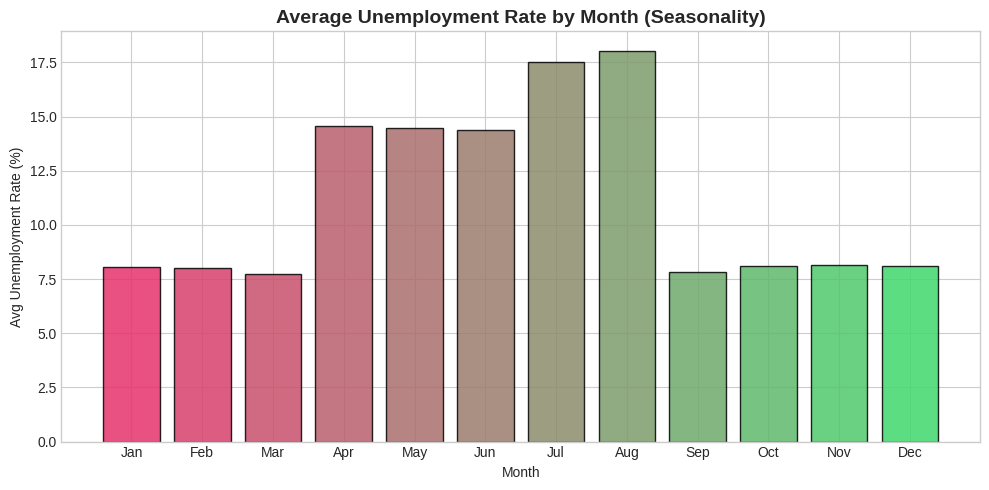

    Saved: unemployment_seasonality.png


In [33]:
# 8. MONTHLY SEASONALITY
print("\n[8] Seasonality Analysis...")
monthly_avg = df.groupby('Month')[unemp_col].mean().reset_index()
plt.figure(figsize=(10, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.bar(monthly_avg['Month'], monthly_avg[unemp_col],
        color=[f'#{int(230-i*15):02x}{int(50+i*15):02x}6c' for i in range(12)],
        edgecolor='black', alpha=0.85)
plt.xticks(range(1, 13), month_names)
plt.title('Average Unemployment Rate by Month (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('unemployment_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: unemployment_seasonality.png")

In [26]:
# 9. SUMMARY
print("\n[9] Final Summary Statistics:")
print(f"    Overall Mean Unemployment  : {df[unemp_col].mean():.2f}%")
print(f"    Overall Median Unemployment: {df[unemp_col].median():.2f}%")
print(f"    Peak Unemployment Rate     : {df[unemp_col].max():.2f}%")
print(f"    Minimum Unemployment Rate  : {df[unemp_col].min():.2f}%")
print(f"    COVID-19 caused avg rate   : {df[df['Period'].str.contains('COVID')][unemp_col].mean():.2f}%")

print("\n" + "=" * 60)
print("  UNEMPLOYMENT ANALYSIS COMPLETE!")
print("=" * 60)


[9] Final Summary Statistics:
    Overall Mean Unemployment  : 11.24%
    Overall Median Unemployment: 9.14%
    Peak Unemployment Rate     : 34.19%
    Minimum Unemployment Rate  : 1.00%
    COVID-19 caused avg rate   : 11.24%

  UNEMPLOYMENT ANALYSIS COMPLETE!
